# OneKeyCash Micro-Reward Financial Analysis

This notebook evaluates how Expedia could use **small OneKeyCash incentives** to increase completion of adaptive review follow-up questions, especially for travelers with non-extreme opinions.

The notebook combines:

- official public facts about **One Key** and **Expedia Group**
- the local hotel review dataset for this hackathon
- a scenario model for **reward cost**, **incremental review lift**, and **break-even economics**

The focus is not on exact internal accounting, which is not public. Instead, this notebook builds a transparent sensitivity model that can support a product recommendation in the pitch.


## Research Notes

Public facts in this notebook are based on official Expedia / Expedia Group / SEC materials checked on **April 14, 2026**.

Key official facts used:

- **OneKeyCash value**: `$1 in OneKeyCash = $1 discount` on eligible redemption rewards.
- **OneKeyCash earn rate**: generally `2%` on eligible hotels, cars, activities, cruises, and many rentals; `0.2%` on eligible flights.
- **OneKeyCash funding**: Expedia Group states that it **funds the cost of OneKeyCash**, so partners are not expected to absorb it.
- **Member value**: Expedia Group states that One Key members generate `3x gross bookings per customer`, `2.5x gross profit per customer`, and `3x repeat business` vs non-members.
- **Expedia scale**: Expedia Group reported **$119.59B gross bookings** and **$14.733B revenue** for full-year 2025.

Important modeling note:

- The **true economic cost** to Expedia of a promotional $1 OneKeyCash credit is **not publicly disclosed**.
- This notebook therefore models:
  - **face-value cost** to the traveler
  - **redemption-adjusted cost**
  - **economic cost** after a configurable Expedia cost realization factor


In [1]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, FuncFormatter
from IPython.display import display, Markdown


DATA_DIR = Path(".")
OUTPUT_DIR = DATA_DIR / "reward_financial_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

PALETTE = {
    "navy": "#0B1F3A",
    "blue": "#2C7FB8",
    "sky": "#89BEDC",
    "teal": "#1B998B",
    "gold": "#F3A712",
    "red": "#D1495B",
    "gray": "#6B7280",
    "light_gray": "#E5E7EB",
    "green": "#2F855A",
}

plt.style.use("default")
plt.rcParams.update(
    {
        "figure.figsize": (11, 6),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "font.size": 10,
    }
)

pd.options.display.float_format = lambda x: f"{x:,.4f}"


def usd(x):
    return f"${x:,.2f}"


def usd_mm(x):
    return f"${x/1_000_000:,.2f}M"


def pct(x):
    return f"{x:.1%}"


def savefig(fig, name):
    fig.savefig(OUTPUT_DIR / f"{name}.png", bbox_inches="tight", dpi=220)
    fig.savefig(OUTPUT_DIR / f"{name}.svg", bbox_inches="tight")
    plt.show()


print(f"Outputs will be saved to: {OUTPUT_DIR.resolve()}")


Outputs will be saved to: C:\VS Code\Projects\Wharton Hack-AI-Thon\reward_financial_outputs


In [2]:
research_sources = pd.DataFrame(
    [
        {
            "source": "Expedia One Key Terms and Conditions",
            "date": "Effective Aug 13, 2025",
            "url": "https://www.expedia.com/lp/b/exp-rewards-terms",
            "key_fact": "$1 in OneKeyCash provides a $1 discount; hotels/cars/activities/cruises generally earn 2%; flights earn 0.2%; OneKeyCash is not redeemable for cash; inactivity expiry is 18 months.",
        },
        {
            "source": "One Key Cards by Expedia",
            "date": "Checked Apr 14, 2026",
            "url": "https://www.expedia.com/one-key-cards",
            "key_fact": "Expedia states that $1 in OneKeyCash is $1 to use on eligible hotels, car rentals, flights, and more.",
        },
        {
            "source": "Expedia Group partner page: distribute your inventory",
            "date": "Checked Apr 14, 2026",
            "url": "https://partner.expediagroup.com/en-us/solutions/distribute-your-inventory",
            "key_fact": "More than 168 million members; Expedia Group-funded OneKeyCash; members spend more and book more often than non-members.",
        },
        {
            "source": "Expedia Group partner page: One Key hotel strategy",
            "date": "Checked Apr 14, 2026",
            "url": "https://partner.expediagroup.com/en-us/resources/blog/one-key-hotel-strategy",
            "key_fact": "Expedia internal data says One Key members drive 3x gross bookings per customer, 2.5x gross profit per customer, and 3x repeat business vs non-members.",
        },
        {
            "source": "Expedia Group Q4 / full-year 2025 earnings release",
            "date": "Feb 12, 2026",
            "url": "https://www.sec.gov/Archives/edgar/data/1324424/000132442426000005/earningsrelease-q42025.htm",
            "key_fact": "Full-year 2025 gross bookings were $119.59B and revenue was $14.733B. The release also provides quarterly B2C gross bookings, revenue, adjusted EBITDA, and direct selling/marketing expense.",
        },
    ]
)

display(Markdown("## Public Source Table"))
display(research_sources)


## Public Source Table

,source,date,url,key_fact
0,Expedia One Key Terms and Conditions,"Effective Aug 13, 2025",https://www.expedia.com/lp/b/exp-rewards-terms,$1 in OneKeyCash provides a $1 discount; hotel...
1,One Key Cards by Expedia,"Checked Apr 14, 2026",https://www.expedia.com/one-key-cards,Expedia states that $1 in OneKeyCash is $1 to ...
2,Expedia Group partner page: distribute your in...,"Checked Apr 14, 2026",https://partner.expediagroup.com/en-us/solutio...,More than 168 million members; Expedia Group-f...
3,Expedia Group partner page: One Key hotel stra...,"Checked Apr 14, 2026",https://partner.expediagroup.com/en-us/resourc...,Expedia internal data says One Key members dri...
4,Expedia Group Q4 / full-year 2025 earnings rel...,"Feb 12, 2026",https://www.sec.gov/Archives/edgar/data/132442...,Full-year 2025 gross bookings were $119.59B an...


In [3]:
reviews_raw = pd.read_csv(DATA_DIR / "Reviews_PROC.csv")
rating_json = reviews_raw["rating"].apply(json.loads)
rating_frame = rating_json.apply(pd.Series)
rating_frame = rating_frame.apply(pd.to_numeric, errors="coerce").fillna(0)

reviews = pd.concat([reviews_raw.drop(columns=["rating"]), rating_frame], axis=1)
reviews["acquisition_date"] = pd.to_datetime(reviews["acquisition_date"], errors="coerce")
reviews["review_title"] = reviews["review_title"].fillna("").astype(str)
reviews["review_text"] = reviews["review_text"].fillna("").astype(str)
reviews["review_full_text"] = (reviews["review_title"] + " " + reviews["review_text"]).str.strip()
reviews["word_count"] = reviews["review_full_text"].str.split().str.len().fillna(0).astype(int)
reviews["has_text"] = reviews["review_text"].str.strip().ne("")
reviews["has_title"] = reviews["review_title"].str.strip().ne("")
reviews["overall_rating"] = pd.to_numeric(reviews["overall"], errors="coerce").replace(0, np.nan)

reviews = reviews.dropna(subset=["overall_rating"]).copy()

reviews["moderate_rating"] = reviews["overall_rating"].between(3, 4)
reviews["extreme_rating"] = reviews["overall_rating"].isin([1, 2, 5])
reviews["short_or_missing_text"] = (~reviews["has_text"]) | (reviews["word_count"] < 20)
reviews["quiet_majority_candidate"] = reviews["moderate_rating"] | reviews["short_or_missing_text"]

dataset_snapshot = pd.DataFrame(
    [
        ("Reviews with overall rating", len(reviews)),
        ("Moderate-rating share (3 or 4 stars)", reviews["moderate_rating"].mean()),
        ("Extreme-rating share (1, 2, or 5 stars)", reviews["extreme_rating"].mean()),
        ("Short-or-missing-text share", reviews["short_or_missing_text"].mean()),
        ("Quiet-majority candidate share", reviews["quiet_majority_candidate"].mean()),
    ],
    columns=["Metric", "Value"],
)

dataset_snapshot.to_csv(OUTPUT_DIR / "dataset_snapshot.csv", index=False)
display(Markdown("## Quiet-Majority Sizing From the Local Dataset"))
display(dataset_snapshot)


## Quiet-Majority Sizing From the Local Dataset

,Metric,Value
0,Reviews with overall rating,"5,999.0000"
1,Moderate-rating share (3 or 4 stars),0.3519
2,"Extreme-rating share (1, 2, or 5 stars)",0.6481
3,Short-or-missing-text share,0.6794
4,Quiet-majority candidate share,0.8131


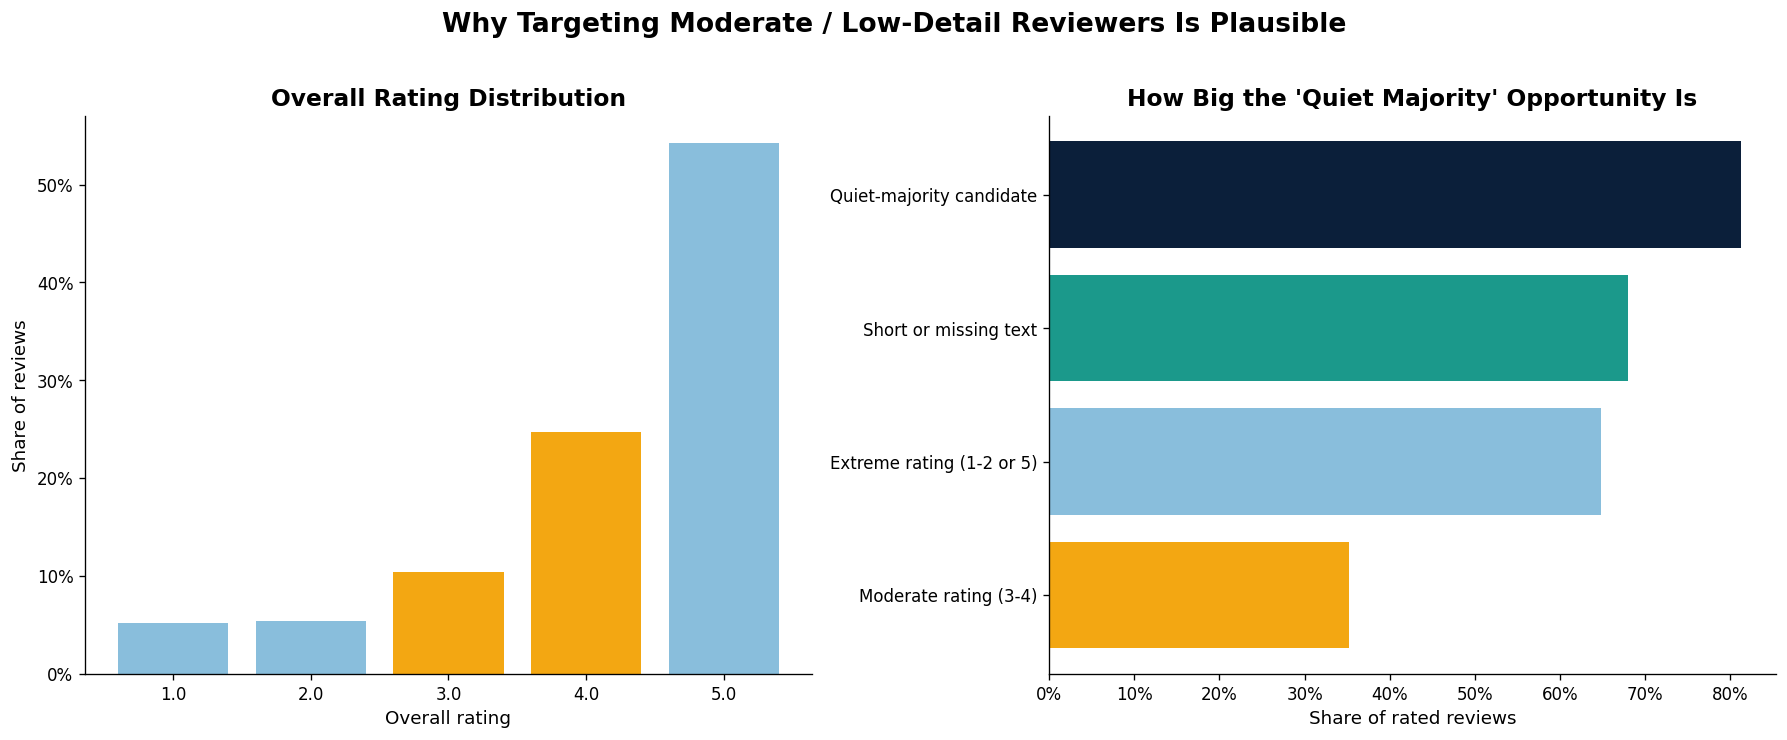

In [4]:
rating_dist = (
    reviews["overall_rating"]
    .value_counts(normalize=True)
    .sort_index()
    .rename_axis("overall_rating")
    .reset_index(name="share")
)

segment_dist = pd.DataFrame(
    {
        "segment": ["Moderate rating (3-4)", "Extreme rating (1-2 or 5)", "Short or missing text", "Quiet-majority candidate"],
        "share": [
            reviews["moderate_rating"].mean(),
            reviews["extreme_rating"].mean(),
            reviews["short_or_missing_text"].mean(),
            reviews["quiet_majority_candidate"].mean(),
        ],
    }
)
segment_dist.to_csv(OUTPUT_DIR / "target_segment_shares.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors = [PALETTE["gold"] if x in [3, 4] else PALETTE["sky"] for x in rating_dist["overall_rating"]]
axes[0].bar(rating_dist["overall_rating"].astype(str), rating_dist["share"], color=colors)
axes[0].set_title("Overall Rating Distribution")
axes[0].set_xlabel("Overall rating")
axes[0].set_ylabel("Share of reviews")
axes[0].yaxis.set_major_formatter(PercentFormatter(1))

axes[1].barh(segment_dist["segment"], segment_dist["share"], color=[PALETTE["gold"], PALETTE["sky"], PALETTE["teal"], PALETTE["navy"]])
axes[1].set_title("How Big the 'Quiet Majority' Opportunity Is")
axes[1].set_xlabel("Share of rated reviews")
axes[1].xaxis.set_major_formatter(PercentFormatter(1))

fig.suptitle("Why Targeting Moderate / Low-Detail Reviewers Is Plausible", fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
savefig(fig, "01_quiet_majority_sizing")


In [5]:
public_facts = {
    "onekeycash_redemption_value": 1.00,
    "onekeycash_base_earn_rate_hotel_like": 0.02,
    "onekeycash_base_earn_rate_flight": 0.002,
    "onekey_members_millions": 168,
    "member_booking_multiplier": 3.0,
    "member_gross_profit_multiplier": 2.5,
    "member_repeat_business_multiplier": 3.0,
    "expedia_2025_gross_bookings": 119.590e9,
    "expedia_2025_revenue": 14.733e9,
}

b2c_2025 = {
    "gross_bookings": np.array([22.615e9, 21.565e9, 21.343e9, 18.344e9]).sum(),
    "revenue": np.array([1.956e9, 2.479e9, 2.883e9, 2.156e9]).sum(),
    "adjusted_ebitda": np.array([0.217e9, 0.728e9, 1.174e9, 0.679e9]).sum(),
    "direct_selling_marketing": np.array([1.757e9, 1.920e9, 1.976e9, 1.696e9]).sum(),
}

derived_facts = pd.DataFrame(
    [
        ("OneKeyCash traveler value", "$1 OKC = $1 discount"),
        ("Hotel-like base earn rate", "2%"),
        ("Flight base earn rate", "0.2%"),
        ("One Key member scale", "168M+ members"),
        ("Expedia 2025 total revenue margin", pct(public_facts["expedia_2025_revenue"] / public_facts["expedia_2025_gross_bookings"])),
        ("Expedia 2025 B2C revenue margin (derived)", pct(b2c_2025["revenue"] / b2c_2025["gross_bookings"])),
        ("Expedia 2025 B2C adj. EBITDA margin on gross bookings (derived)", pct(b2c_2025["adjusted_ebitda"] / b2c_2025["gross_bookings"])),
        ("Expedia 2025 direct selling / marketing as % of gross bookings (derived)", pct(b2c_2025["direct_selling_marketing"] / public_facts["expedia_2025_gross_bookings"])),
    ],
    columns=["Metric", "Value"],
)

derived_facts.to_csv(OUTPUT_DIR / "public_facts_summary.csv", index=False)
display(Markdown("## Public Facts Used in the Model"))
display(derived_facts)


## Public Facts Used in the Model

,Metric,Value
0,OneKeyCash traveler value,$1 OKC = $1 discount
1,Hotel-like base earn rate,2%
2,Flight base earn rate,0.2%
3,One Key member scale,168M+ members
4,Expedia 2025 total revenue margin,12.3%
5,Expedia 2025 B2C revenue margin (derived),11.3%
6,Expedia 2025 B2C adj. EBITDA margin on gross b...,3.3%
7,Expedia 2025 direct selling / marketing as % o...,6.1%


## Modeling Approach

This is a **decision notebook**, not an internal accounting document.

Because Expedia does not publicly disclose the true cost recognition mechanics for a promotional OneKeyCash dollar, the model separates three levels of cost:

1. **Issued face value**: how much OneKeyCash is granted to travelers.
2. **Redemption-adjusted face value**: issued face value multiplied by expected redemption rate.
3. **Economic cost to Expedia**: redemption-adjusted face value multiplied by an assumed cost realization ratio.

The cost realization ratio exists because a $1 traveler discount does not necessarily imply a $1 economic loss to Expedia on every redemption, especially if redemptions occur on inventory with margin. That ratio is therefore modeled as a sensitivity input, not a sourced fact.

The notebook also assumes that the strongest product design is **hybrid**:

- non-cash motivation: social card, impact preview, helpful reviewer badge, better personalization
- cash motivation: a small OneKeyCash reward for completing the adaptive follow-up

This matters because non-cash incentives should reduce the amount of OneKeyCash needed.


In [6]:
reward_levels = np.array([0.00, 0.25, 0.50, 0.75, 1.00, 1.50, 2.00, 3.00])

annual_invites = 1_000_000
average_incremental_booking_value = 300.0
b2c_revenue_per_gross_booking = b2c_2025["revenue"] / b2c_2025["gross_bookings"]
b2c_ebitda_per_gross_booking = b2c_2025["adjusted_ebitda"] / b2c_2025["gross_bookings"]

moderate_target_share = float(reviews["moderate_rating"].mean())

scenario_specs = {
    "Universal reward": {
        "target_share": 1.00,
        "baseline_completion_rate": 0.18,
        "social_bundle_lift_pp": 0.020,
        "max_cash_lift_pp": 0.040,
        "curve_k": 1.15,
    },
    "Moderate-rating targeted": {
        "target_share": moderate_target_share,
        "baseline_completion_rate": 0.14,
        "social_bundle_lift_pp": 0.025,
        "max_cash_lift_pp": 0.055,
        "curve_k": 1.40,
    },
}

sensitivity_specs = {
    "Conservative": {"redemption_rate": 0.90, "cost_realization_ratio": 1.00, "lift_scale": 0.80},
    "Base": {"redemption_rate": 0.80, "cost_realization_ratio": 0.70, "lift_scale": 1.00},
    "Optimistic": {"redemption_rate": 0.65, "cost_realization_ratio": 0.55, "lift_scale": 1.15},
}


def cash_lift(reward_amount, max_cash_lift_pp, curve_k, lift_scale=1.0):
    return lift_scale * max_cash_lift_pp * (1 - np.exp(-curve_k * reward_amount))


def evaluate_program(label, reward_values, sensitivity_label="Base"):
    spec = scenario_specs[label]
    sens = sensitivity_specs[sensitivity_label]
    rows = []
    target_invites = annual_invites * spec["target_share"]
    social_only_rate = spec["baseline_completion_rate"] + spec["social_bundle_lift_pp"]
    social_only_reviews = target_invites * social_only_rate

    for reward in reward_values:
        reward_lift = cash_lift(
            reward,
            spec["max_cash_lift_pp"],
            spec["curve_k"],
            sens["lift_scale"],
        )
        final_completion_rate = min(0.95, social_only_rate + reward_lift)
        completed_reviews = target_invites * final_completion_rate
        additional_reviews = completed_reviews - social_only_reviews

        issued_face_value = completed_reviews * reward
        redeemed_face_value = issued_face_value * sens["redemption_rate"]
        economic_cost = redeemed_face_value * sens["cost_realization_ratio"]

        rows.append(
            {
                "scenario": label,
                "sensitivity": sensitivity_label,
                "reward_amount": reward,
                "target_share": spec["target_share"],
                "target_invites": target_invites,
                "social_only_completion_rate": social_only_rate,
                "final_completion_rate": final_completion_rate,
                "completed_reviews": completed_reviews,
                "additional_reviews_vs_social_only": additional_reviews,
                "issued_face_value": issued_face_value,
                "redeemed_face_value": redeemed_face_value,
                "economic_cost": economic_cost,
                "cost_per_additional_review": np.nan if additional_reviews <= 0 else economic_cost / additional_reviews,
                "hotel_spend_equivalent_per_user": np.nan if reward <= 0 else reward / public_facts["onekeycash_base_earn_rate_hotel_like"],
                "revenue_break_even_gross_bookings": np.nan if b2c_revenue_per_gross_booking == 0 else economic_cost / b2c_revenue_per_gross_booking,
                "ebitda_break_even_gross_bookings": np.nan if b2c_ebitda_per_gross_booking == 0 else economic_cost / b2c_ebitda_per_gross_booking,
                "required_repeat_booking_conversion": np.nan
                if additional_reviews <= 0
                else economic_cost / (additional_reviews * average_incremental_booking_value * b2c_ebitda_per_gross_booking),
            }
        )
    return pd.DataFrame(rows)


base_results = pd.concat(
    [evaluate_program(name, reward_levels, "Base") for name in scenario_specs],
    ignore_index=True,
)
base_results.to_csv(OUTPUT_DIR / "base_reward_scenarios.csv", index=False)

display(Markdown("## Base Scenario Results"))
display(base_results)


## Base Scenario Results

,scenario,sensitivity,reward_amount,target_share,target_invites,social_only_completion_rate,final_completion_rate,completed_reviews,additional_reviews_vs_social_only,issued_face_value,redeemed_face_value,economic_cost,cost_per_additional_review,hotel_spend_equivalent_per_user,revenue_break_even_gross_bookings,ebitda_break_even_gross_bookings,required_repeat_booking_conversion
0,Universal reward,Base,0.0000,1.0000,"1,000,000.0000",0.2000,0.2000,"200,000.0000",0.0000,0.0000,0.0000,0.0000,NaN,NaN,0.0000,0.0000,NaN
1,Universal reward,Base,0.2500,1.0000,"1,000,000.0000",0.2000,0.2100,"209,994.5373","9,994.5373","52,498.6343","41,998.9075","29,399.2352",2.9415,12.5000,"260,251.8113","881,210.0288",0.2939
2,Universal reward,Base,0.5000,1.0000,"1,000,000.0000",0.2000,0.2175,"217,491.8052","17,491.8052","108,745.9026","86,996.7221","60,897.7055",3.4815,25.0000,"539,086.7495","1,825,342.3390",0.3478
3,Universal reward,Base,0.7500,1.0000,"1,000,000.0000",0.2000,0.2231,"223,115.7801","23,115.7801","167,336.8350","133,869.4680","93,708.6276",4.0539,37.5000,"829,539.9486","2,808,813.9647",0.4050
4,Universal reward,Base,1.0000,1.0000,"1,000,000.0000",0.2000,0.2273,"227,334.5292","27,334.5292","227,334.5292","181,867.6234","127,307.3364",4.6574,50.0000,"1,126,966.8967","3,815,898.6344",0.4653
5,Universal reward,Base,1.5000,1.0000,"1,000,000.0000",0.2000,0.2329,"232,873.0779","32,873.0779","349,309.6169","279,447.6935","195,613.3855",5.9506,75.0000,"1,731,634.7687","5,863,297.9980",0.5945
6,Universal reward,Base,2.0000,1.0000,"1,000,000.0000",0.2000,0.2360,"235,989.6463","35,989.6463","471,979.2925","377,583.4340","264,308.4038",7.3440,100.0000,"2,339,745.9259","7,922,356.2908",0.7338
7,Universal reward,Base,3.0000,1.0000,"1,000,000.0000",0.2000,0.2387,"238,730.1745","38,730.1745","716,190.5236","572,952.4189","401,066.6932",10.3554,150.0000,"3,550,375.8034","12,021,536.9412",1.0346
8,Moderate-rating targeted,Base,0.0000,0.3519,"351,891.9820",0.1650,0.1650,"58,062.1770",0.0000,0.0000,0.0000,0.0000,NaN,NaN,0.0000,0.0000,NaN
9,Moderate-rating targeted,Base,0.2500,0.3519,"351,891.9820",0.1650,0.1812,"63,777.6612","5,715.4841","15,944.4153","12,755.5322","8,928.8726",1.5622,12.5000,"79,041.3506","267,633.2220",0.1561


In [7]:
summary_view = base_results.loc[
    base_results["reward_amount"].isin([0.25, 0.50, 1.00, 2.00]),
    [
        "scenario",
        "reward_amount",
        "final_completion_rate",
        "additional_reviews_vs_social_only",
        "economic_cost",
        "cost_per_additional_review",
        "required_repeat_booking_conversion",
    ],
].copy()
summary_view.to_csv(OUTPUT_DIR / "summary_view.csv", index=False)
display(Markdown("## Summary Cut for Common Reward Levels"))
display(summary_view)


## Summary Cut for Common Reward Levels

,scenario,reward_amount,final_completion_rate,additional_reviews_vs_social_only,economic_cost,cost_per_additional_review,required_repeat_booking_conversion
1,Universal reward,0.2500,0.2100,"9,994.5373","29,399.2352",2.9415,0.2939
2,Universal reward,0.5000,0.2175,"17,491.8052","60,897.7055",3.4815,0.3478
4,Universal reward,1.0000,0.2273,"27,334.5292","127,307.3364",4.6574,0.4653
6,Universal reward,2.0000,0.2360,"35,989.6463","264,308.4038",7.3440,0.7338
9,Moderate-rating targeted,0.2500,0.1812,"5,715.4841","8,928.8726",1.5622,0.1561
10,Moderate-rating targeted,0.5000,0.1927,"9,743.1177","18,985.4825",1.9486,0.1947
12,Moderate-rating targeted,1.0000,0.2064,"14,581.4068","40,680.4070",2.7899,0.2787
14,Moderate-rating targeted,2.0000,0.2167,"18,177.1375","85,388.0322",4.6976,0.4693


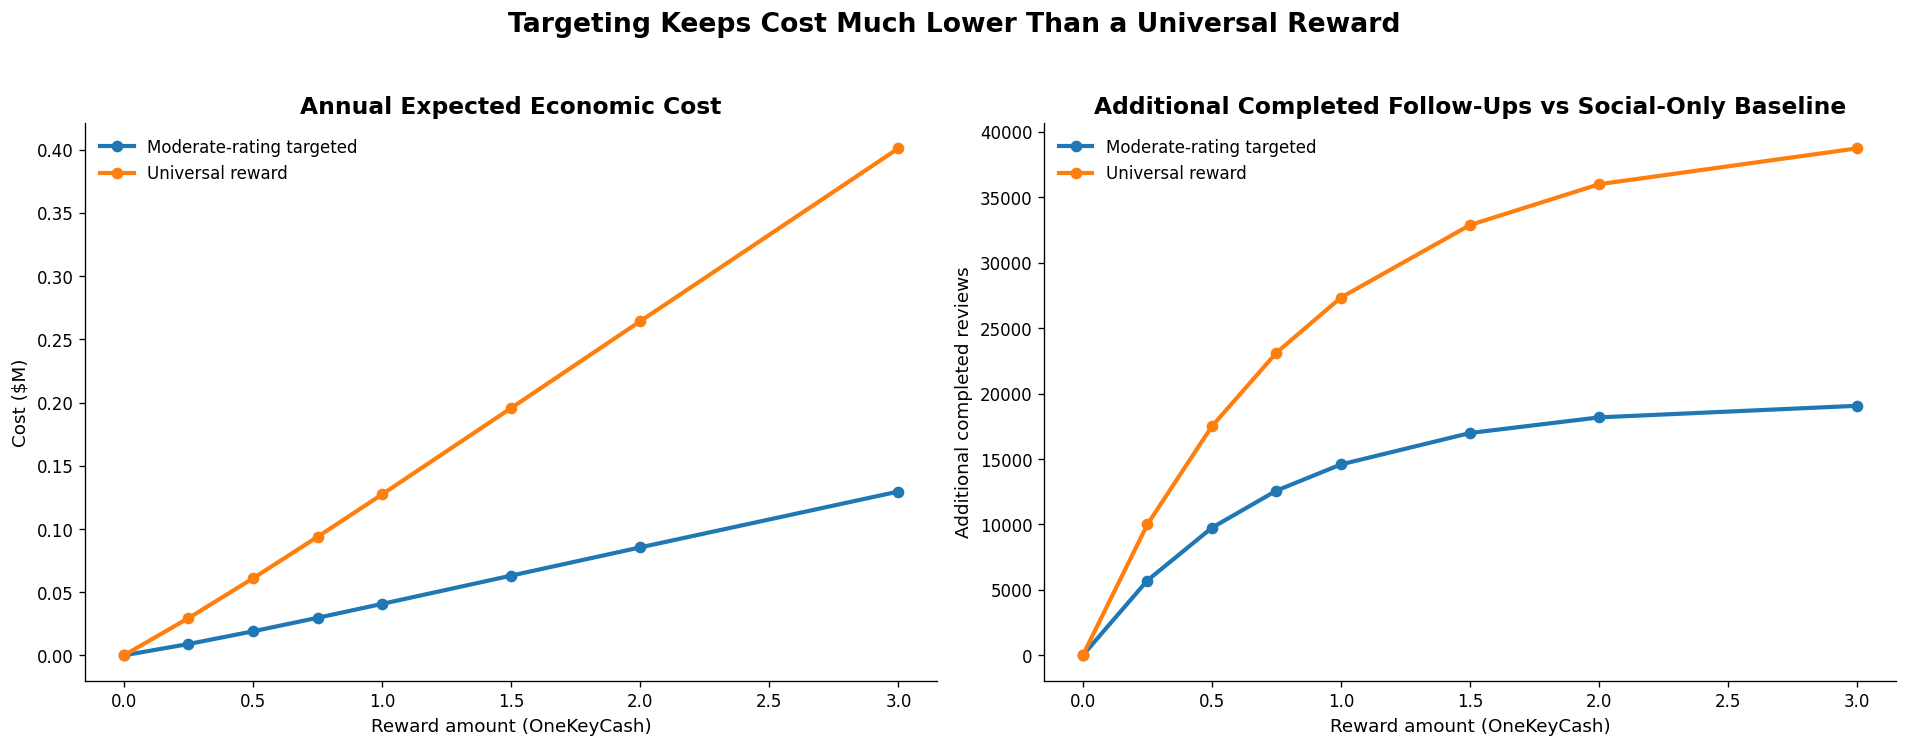

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for scenario_name, df in base_results.groupby("scenario"):
    axes[0].plot(df["reward_amount"], df["economic_cost"] / 1_000_000, marker="o", linewidth=2.5, label=scenario_name)
    axes[1].plot(df["reward_amount"], df["additional_reviews_vs_social_only"], marker="o", linewidth=2.5, label=scenario_name)

axes[0].set_title("Annual Expected Economic Cost")
axes[0].set_xlabel("Reward amount (OneKeyCash)")
axes[0].set_ylabel("Cost ($M)")

axes[1].set_title("Additional Completed Follow-Ups vs Social-Only Baseline")
axes[1].set_xlabel("Reward amount (OneKeyCash)")
axes[1].set_ylabel("Additional completed reviews")

for ax in axes:
    ax.legend(frameon=False)

fig.suptitle("Targeting Keeps Cost Much Lower Than a Universal Reward", fontsize=16, fontweight="bold", y=1.03)
fig.tight_layout()
savefig(fig, "02_cost_and_lift_by_reward")


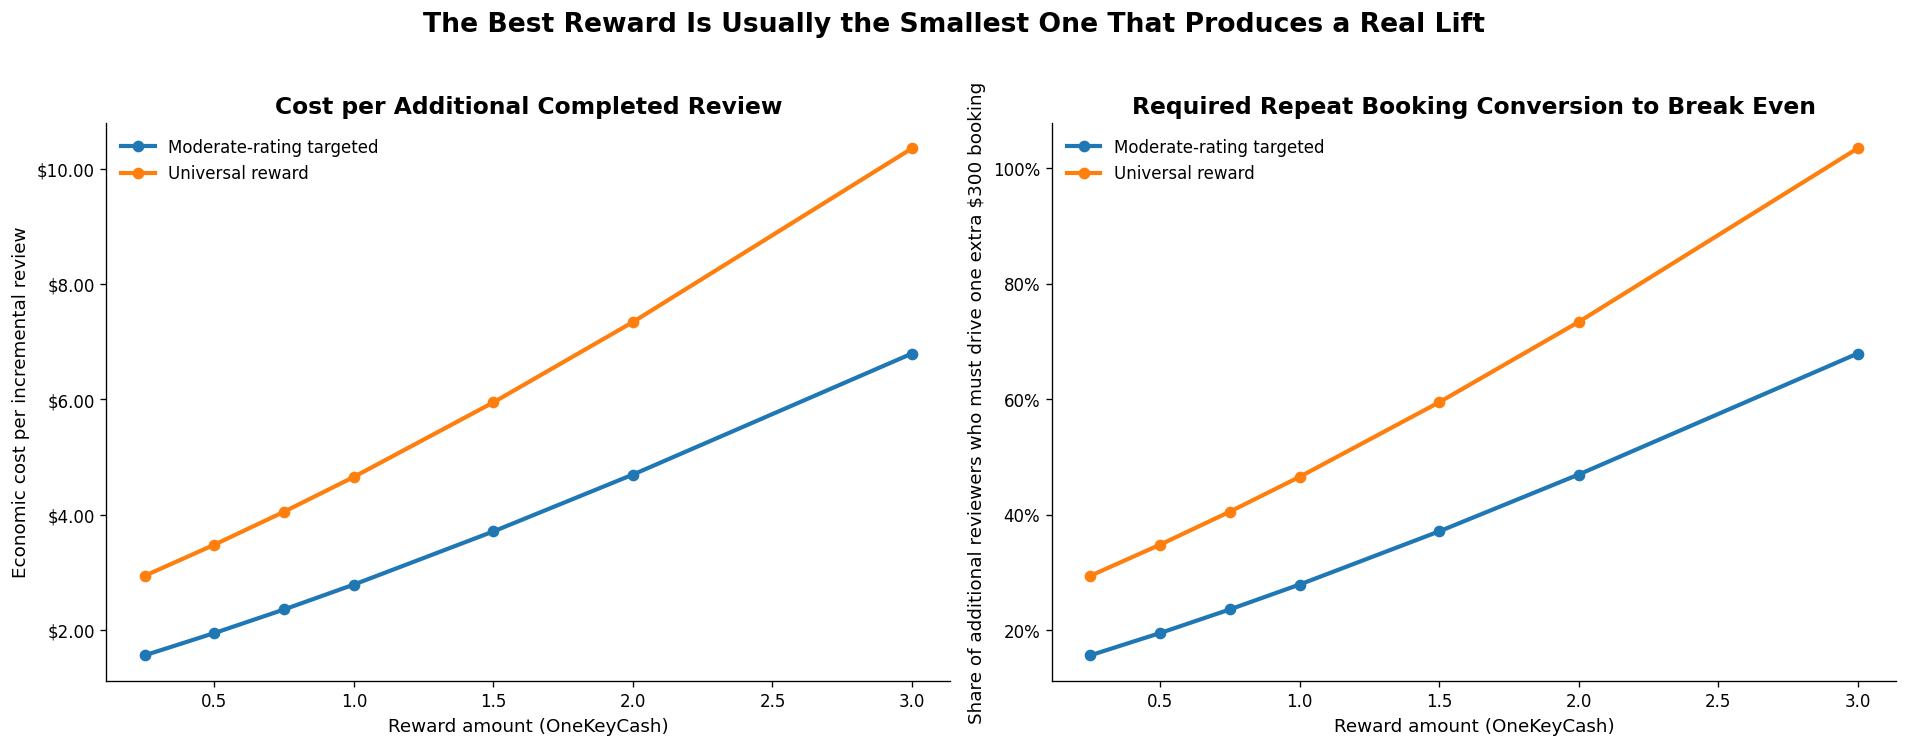

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for scenario_name, df in base_results.groupby("scenario"):
    filtered = df.loc[df["reward_amount"] > 0]
    axes[0].plot(filtered["reward_amount"], filtered["cost_per_additional_review"], marker="o", linewidth=2.5, label=scenario_name)
    axes[1].plot(filtered["reward_amount"], filtered["required_repeat_booking_conversion"], marker="o", linewidth=2.5, label=scenario_name)

axes[0].set_title("Cost per Additional Completed Review")
axes[0].set_xlabel("Reward amount (OneKeyCash)")
axes[0].set_ylabel("Economic cost per incremental review")
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x:,.2f}"))

axes[1].set_title("Required Repeat Booking Conversion to Break Even")
axes[1].set_xlabel("Reward amount (OneKeyCash)")
axes[1].set_ylabel("Share of additional reviewers who must drive one extra $300 booking")
axes[1].yaxis.set_major_formatter(PercentFormatter(1))

for ax in axes:
    ax.legend(frameon=False)

fig.suptitle("The Best Reward Is Usually the Smallest One That Produces a Real Lift", fontsize=16, fontweight="bold", y=1.03)
fig.tight_layout()
savefig(fig, "03_efficiency_and_breakeven")


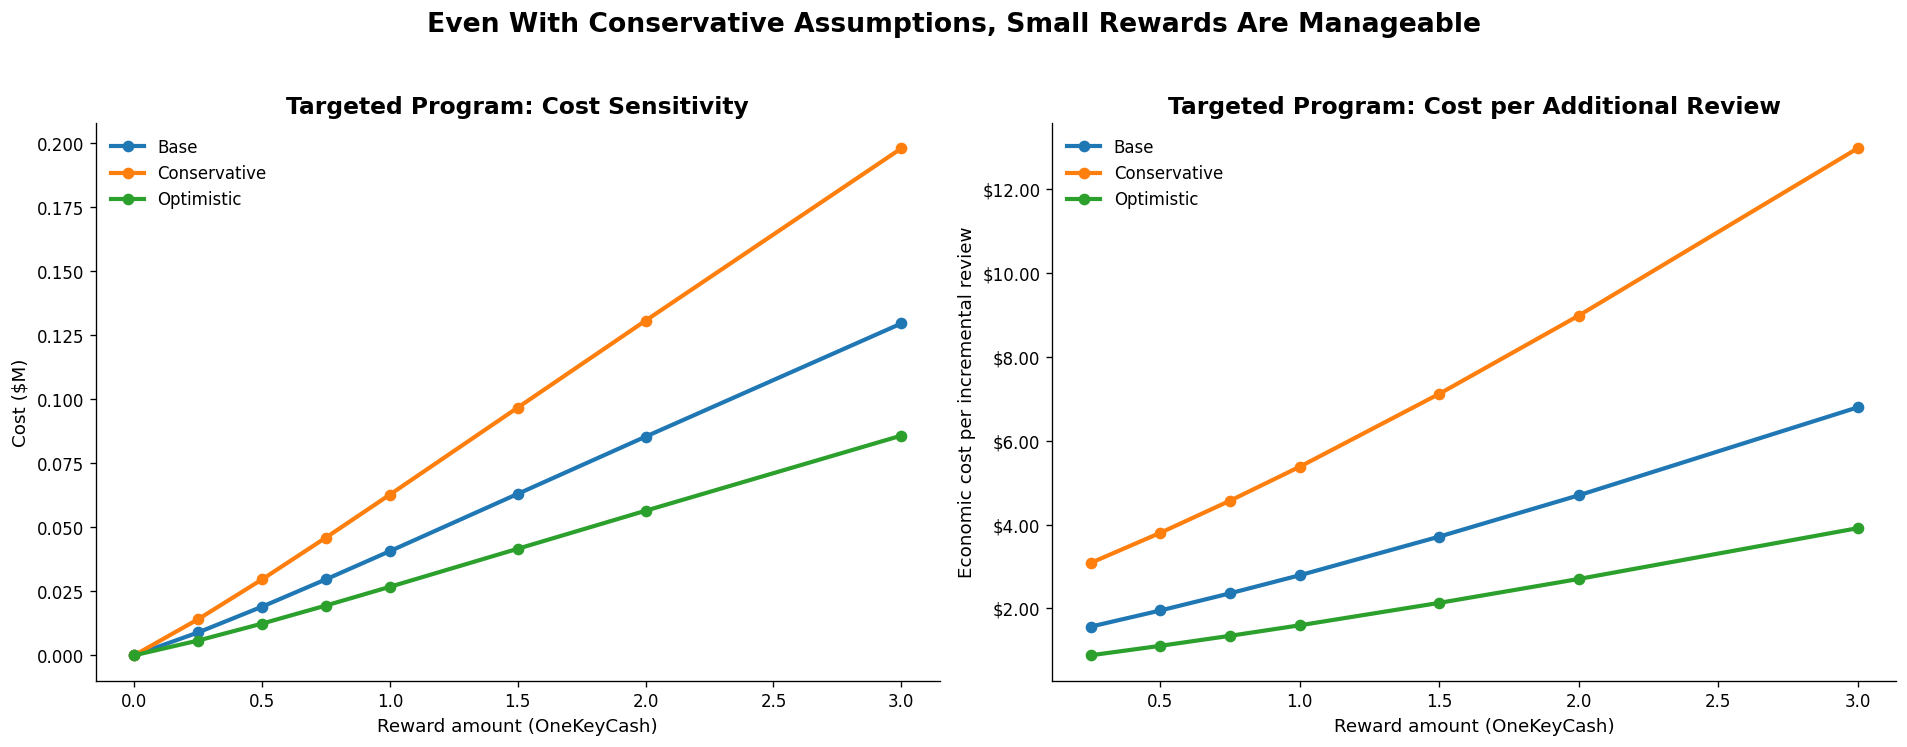

In [10]:
targeted_sensitivity = pd.concat(
    [evaluate_program("Moderate-rating targeted", reward_levels, sens) for sens in sensitivity_specs],
    ignore_index=True,
)
targeted_sensitivity.to_csv(OUTPUT_DIR / "targeted_sensitivity.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for sensitivity_name, df in targeted_sensitivity.groupby("sensitivity"):
    axes[0].plot(df["reward_amount"], df["economic_cost"] / 1_000_000, marker="o", linewidth=2.5, label=sensitivity_name)
    axes[1].plot(df["reward_amount"], df["cost_per_additional_review"], marker="o", linewidth=2.5, label=sensitivity_name)

axes[0].set_title("Targeted Program: Cost Sensitivity")
axes[0].set_xlabel("Reward amount (OneKeyCash)")
axes[0].set_ylabel("Cost ($M)")

axes[1].set_title("Targeted Program: Cost per Additional Review")
axes[1].set_xlabel("Reward amount (OneKeyCash)")
axes[1].set_ylabel("Economic cost per incremental review")
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x:,.2f}"))

for ax in axes:
    ax.legend(frameon=False)

fig.suptitle("Even With Conservative Assumptions, Small Rewards Are Manageable", fontsize=16, fontweight="bold", y=1.03)
fig.tight_layout()
savefig(fig, "04_targeted_sensitivity")


In [11]:
sweepstakes_specs = [
    {"design": "20 winners / week x $50 OKC", "winners_per_period": 20, "prize_amount": 50, "periods_per_year": 52},
    {"design": "50 winners / week x $50 OKC", "winners_per_period": 50, "prize_amount": 50, "periods_per_year": 52},
    {"design": "10 winners / week x $100 OKC", "winners_per_period": 10, "prize_amount": 100, "periods_per_year": 52},
    {"design": "25 winners / week x $100 OKC", "winners_per_period": 25, "prize_amount": 100, "periods_per_year": 52},
]

for sens_name, sens in sensitivity_specs.items():
    sens["sweepstakes_salience_multiplier"] = {
        "Conservative": 0.30,
        "Base": 0.50,
        "Optimistic": 0.70,
    }[sens_name]
    sens["winner_redemption_rate"] = {
        "Conservative": 0.95,
        "Base": 0.95,
        "Optimistic": 0.98,
    }[sens_name]


def evaluate_sweepstakes(label, design, sensitivity_label="Base"):
    spec = scenario_specs[label]
    sens = sensitivity_specs[sensitivity_label]
    target_invites = annual_invites * spec["target_share"]
    social_only_rate = spec["baseline_completion_rate"] + spec["social_bundle_lift_pp"]
    prize_pool = design["winners_per_period"] * design["prize_amount"] * design["periods_per_year"]

    completion_rate = social_only_rate
    guaranteed_equivalent = 0.0
    expected_value_per_completion = 0.0

    for _ in range(25):
        completed_reviews = max(target_invites * completion_rate, 1.0)
        expected_value_per_completion = prize_pool / completed_reviews
        guaranteed_equivalent = expected_value_per_completion * sens["sweepstakes_salience_multiplier"]
        sweepstakes_lift = cash_lift(
            guaranteed_equivalent,
            spec["max_cash_lift_pp"],
            spec["curve_k"],
            sens["lift_scale"],
        )
        new_rate = min(0.95, social_only_rate + sweepstakes_lift)
        if abs(new_rate - completion_rate) < 1e-9:
            break
        completion_rate = new_rate

    completed_reviews = target_invites * completion_rate
    additional_reviews = completed_reviews - (target_invites * social_only_rate)
    redeemed_face_value = prize_pool * sens["winner_redemption_rate"]
    economic_cost = redeemed_face_value * sens["cost_realization_ratio"]

    return {
        "scenario": label,
        "sensitivity": sensitivity_label,
        "design": design["design"],
        "annual_prize_face_value": prize_pool,
        "completed_reviews": completed_reviews,
        "additional_reviews_vs_social_only": additional_reviews,
        "expected_value_per_completion": expected_value_per_completion,
        "guaranteed_equivalent_reward": guaranteed_equivalent,
        "redeemed_face_value": redeemed_face_value,
        "economic_cost": economic_cost,
        "cost_per_additional_review": np.nan if additional_reviews <= 0 else economic_cost / additional_reviews,
        "required_repeat_booking_conversion": np.nan
        if additional_reviews <= 0
        else economic_cost / (additional_reviews * average_incremental_booking_value * b2c_ebitda_per_gross_booking),
    }


sweepstakes_base = pd.DataFrame(
    [evaluate_sweepstakes("Universal reward", design, "Base") for design in sweepstakes_specs]
    + [evaluate_sweepstakes("Moderate-rating targeted", design, "Base") for design in sweepstakes_specs]
)
sweepstakes_base.to_csv(OUTPUT_DIR / "sweepstakes_base_results.csv", index=False)

display(Markdown("## Sweepstakes Base Scenarios"))
display(sweepstakes_base)


## Sweepstakes Base Scenarios

,scenario,sensitivity,design,annual_prize_face_value,completed_reviews,additional_reviews_vs_social_only,expected_value_per_completion,guaranteed_equivalent_reward,redeemed_face_value,economic_cost,cost_per_additional_review,required_repeat_booking_conversion
0,Universal reward,Base,20 winners / week x $50 OKC,52000,"205,418.3621","5,418.3621",0.2531,0.1266,"49,400.0000","34,580.0000",6.3820,0.6376
1,Universal reward,Base,50 winners / week x $50 OKC,130000,"211,890.6260","11,890.6260",0.6135,0.3068,"123,500.0000","86,450.0000",7.2704,0.7264
2,Universal reward,Base,10 winners / week x $100 OKC,52000,"205,418.3621","5,418.3621",0.2531,0.1266,"49,400.0000","34,580.0000",6.3820,0.6376
3,Universal reward,Base,25 winners / week x $100 OKC,130000,"211,890.6260","11,890.6260",0.6135,0.3068,"123,500.0000","86,450.0000",7.2704,0.7264
4,Moderate-rating targeted,Base,20 winners / week x $50 OKC,52000,"66,244.1363","8,181.9593",0.7850,0.3925,"49,400.0000","34,580.0000",4.2264,0.4223
5,Moderate-rating targeted,Base,50 winners / week x $50 OKC,130000,"71,952.2701","13,890.0931",1.8068,0.9034,"123,500.0000","86,450.0000",6.2239,0.6218
6,Moderate-rating targeted,Base,10 winners / week x $100 OKC,52000,"66,244.1363","8,181.9593",0.7850,0.3925,"49,400.0000","34,580.0000",4.2264,0.4223
7,Moderate-rating targeted,Base,25 winners / week x $100 OKC,130000,"71,952.2701","13,890.0931",1.8068,0.9034,"123,500.0000","86,450.0000",6.2239,0.6218


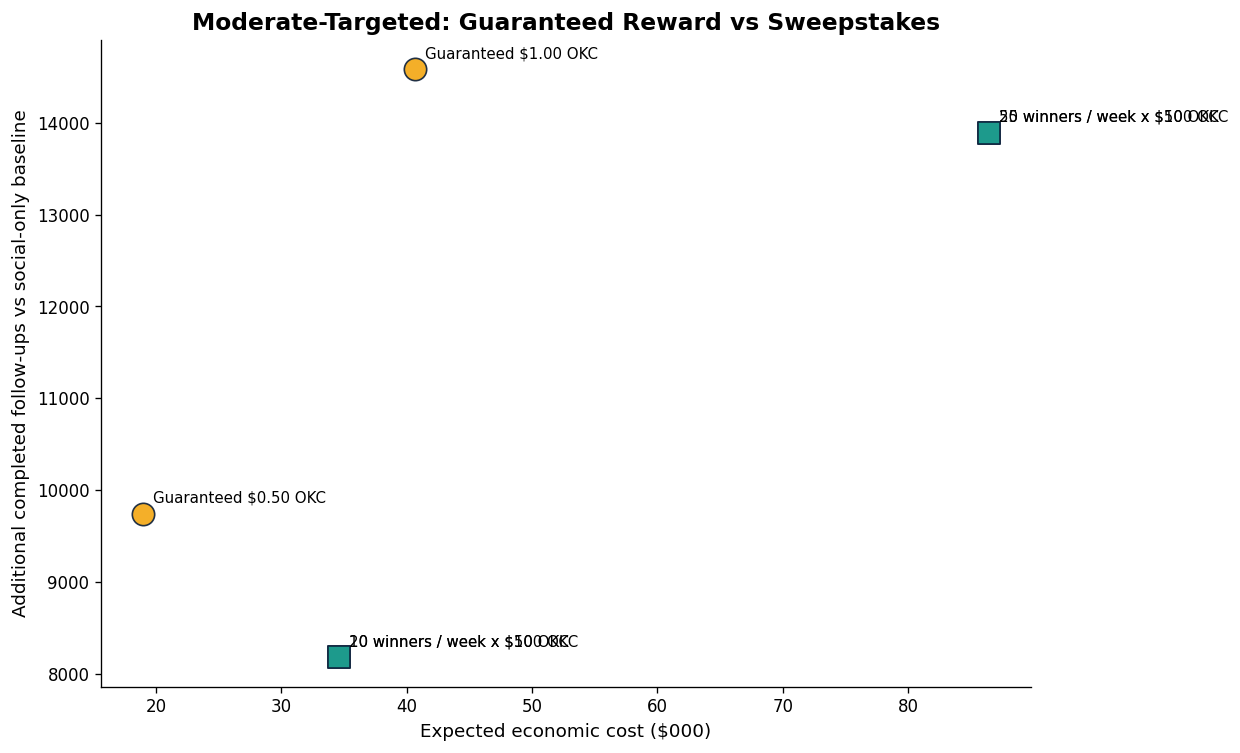

## Guaranteed Reward vs Sweepstakes Comparison

,program,economic_cost,additional_reviews_vs_social_only,cost_per_additional_review
0,Guaranteed $0.50 OKC,"18,985.4825","9,743.1177",1.9486
2,20 winners / week x $50 OKC,"34,580.0000","8,181.9593",4.2264
4,10 winners / week x $100 OKC,"34,580.0000","8,181.9593",4.2264
1,Guaranteed $1.00 OKC,"40,680.4070","14,581.4068",2.7899
3,50 winners / week x $50 OKC,"86,450.0000","13,890.0931",6.2239
5,25 winners / week x $100 OKC,"86,450.0000","13,890.0931",6.2239


In [12]:
micro_compare = base_results.loc[
    (base_results["scenario"] == "Moderate-rating targeted")
    & (base_results["reward_amount"].isin([0.50, 1.00]))
][["scenario", "reward_amount", "economic_cost", "additional_reviews_vs_social_only", "cost_per_additional_review"]].copy()
micro_compare["program"] = micro_compare["reward_amount"].apply(lambda x: f"Guaranteed ${x:.2f} OKC")

sweep_compare = sweepstakes_base.loc[
    sweepstakes_base["scenario"] == "Moderate-rating targeted",
    ["design", "economic_cost", "additional_reviews_vs_social_only", "cost_per_additional_review", "expected_value_per_completion", "guaranteed_equivalent_reward"],
].copy()
sweep_compare = sweep_compare.rename(columns={"design": "program"})

comparison_table = pd.concat(
    [
        micro_compare[["program", "economic_cost", "additional_reviews_vs_social_only", "cost_per_additional_review"]],
        sweep_compare[["program", "economic_cost", "additional_reviews_vs_social_only", "cost_per_additional_review"]],
    ],
    ignore_index=True,
).sort_values("economic_cost")
comparison_table.to_csv(OUTPUT_DIR / "guaranteed_vs_sweepstakes_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 7))
for _, row in comparison_table.iterrows():
    marker = "o" if "Guaranteed" in row["program"] else "s"
    color = PALETTE["gold"] if "Guaranteed" in row["program"] else PALETTE["teal"]
    ax.scatter(
        row["economic_cost"] / 1000,
        row["additional_reviews_vs_social_only"],
        s=180,
        marker=marker,
        color=color,
        edgecolor=PALETTE["navy"],
        alpha=0.9,
    )
    ax.text(
        row["economic_cost"] / 1000 + 0.8,
        row["additional_reviews_vs_social_only"] + 120,
        row["program"],
        fontsize=9,
    )

ax.set_title("Moderate-Targeted: Guaranteed Reward vs Sweepstakes")
ax.set_xlabel("Expected economic cost ($000)")
ax.set_ylabel("Additional completed follow-ups vs social-only baseline")
savefig(fig, "05_guaranteed_vs_sweepstakes")

display(Markdown("## Guaranteed Reward vs Sweepstakes Comparison"))
display(comparison_table)


In [13]:
b2c_revenue_margin = b2c_revenue_per_gross_booking
b2c_ebitda_margin = b2c_ebitda_per_gross_booking

value_compare = comparison_table.copy()
value_compare["required_incremental_gross_bookings"] = value_compare["economic_cost"] / b2c_ebitda_margin
value_compare["required_incremental_revenue"] = value_compare["required_incremental_gross_bookings"] * b2c_revenue_margin
value_compare["incremental_300_dollar_bookings_needed"] = value_compare["required_incremental_gross_bookings"] / average_incremental_booking_value
value_compare.to_csv(OUTPUT_DIR / "value_required_by_program.csv", index=False)

affected_booking_bases = np.array([100e6, 250e6, 500e6, 1e9, 5e9])
uplift_rows = []
for _, row in value_compare.iterrows():
    for base in affected_booking_bases:
        uplift_rows.append(
            {
                "program": row["program"],
                "affected_gross_bookings_base": base,
                "required_gross_bookings_uplift_bps": 10_000 * row["required_incremental_gross_bookings"] / base,
            }
        )

uplift_df = pd.DataFrame(uplift_rows)
uplift_df.to_csv(OUTPUT_DIR / "breakeven_uplift_by_program.csv", index=False)

display(Markdown("## What Better Reviews Need To Be Worth"))
display(value_compare)


## What Better Reviews Need To Be Worth

,program,economic_cost,additional_reviews_vs_social_only,cost_per_additional_review,required_incremental_gross_bookings,required_incremental_revenue,incremental_300_dollar_bookings_needed
0,Guaranteed $0.50 OKC,"18,985.4825","9,743.1177",1.9486,"569,069.1436","64,284.6539","1,896.8971"
2,20 winners / week x $50 OKC,"34,580.0000","8,181.9593",4.2264,"1,036,497.8056","117,087.5340","3,454.9927"
4,10 winners / week x $100 OKC,"34,580.0000","8,181.9593",4.2264,"1,036,497.8056","117,087.5340","3,454.9927"
1,Guaranteed $1.00 OKC,"40,680.4070","14,581.4068",2.7899,"1,219,350.8542","137,743.4509","4,064.5028"
3,50 winners / week x $50 OKC,"86,450.0000","13,890.0931",6.2239,"2,591,244.5139","292,718.8349","8,637.4817"
5,25 winners / week x $100 OKC,"86,450.0000","13,890.0931",6.2239,"2,591,244.5139","292,718.8349","8,637.4817"


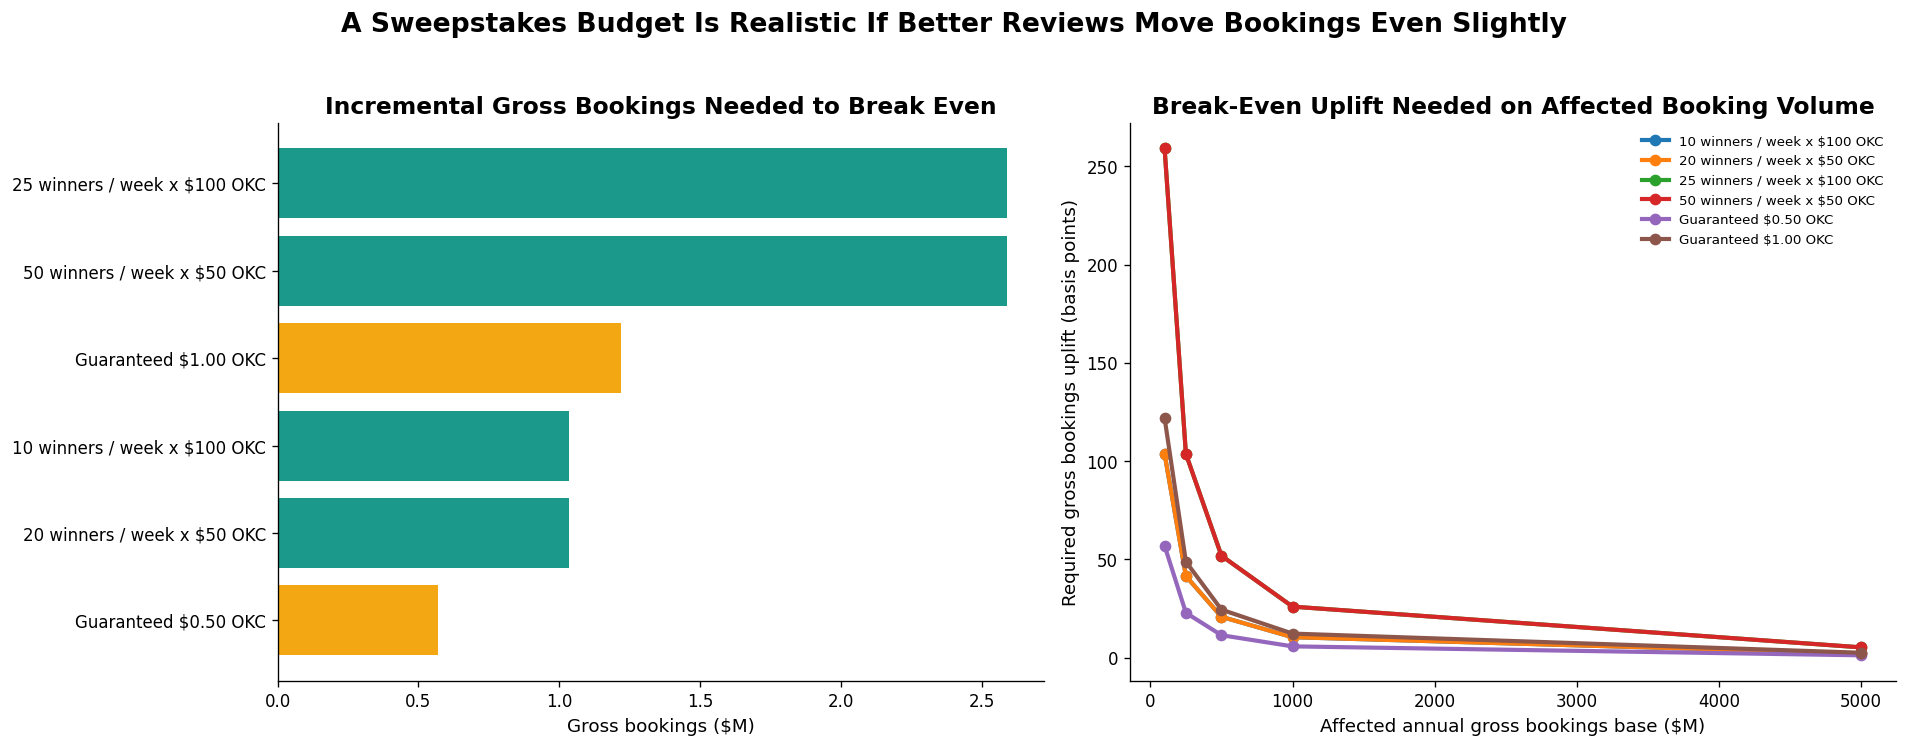

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_df = value_compare.sort_values("required_incremental_gross_bookings")
axes[0].barh(plot_df["program"], plot_df["required_incremental_gross_bookings"] / 1_000_000, color=[PALETTE["gold"] if "Guaranteed" in p else PALETTE["teal"] for p in plot_df["program"]])
axes[0].set_title("Incremental Gross Bookings Needed to Break Even")
axes[0].set_xlabel("Gross bookings ($M)")

pivot = uplift_df.pivot(index="affected_gross_bookings_base", columns="program", values="required_gross_bookings_uplift_bps")
for program in pivot.columns:
    axes[1].plot(pivot.index / 1_000_000, pivot[program], marker="o", linewidth=2.5, label=program)

axes[1].set_title("Break-Even Uplift Needed on Affected Booking Volume")
axes[1].set_xlabel("Affected annual gross bookings base ($M)")
axes[1].set_ylabel("Required gross bookings uplift (basis points)")
axes[1].legend(frameon=False, fontsize=8)

fig.suptitle("A Sweepstakes Budget Is Realistic If Better Reviews Move Bookings Even Slightly", fontsize=16, fontweight="bold", y=1.03)
fig.tight_layout()
savefig(fig, "06_value_needed_to_break_even")


In [15]:
chosen_rows = base_results.loc[
    (base_results["scenario"] == "Moderate-rating targeted")
    & (base_results["reward_amount"].isin([0.50, 1.00]))
].copy()

sweepstakes_options = pd.DataFrame(
    [
        {"design": "20 winners / week x $50 OKC", "annual_budget": 20 * 50 * 52},
        {"design": "50 winners / week x $50 OKC", "annual_budget": 50 * 50 * 52},
        {"design": "10 winners / week x $100 OKC", "annual_budget": 10 * 100 * 52},
        {"design": "25 winners / week x $100 OKC", "annual_budget": 25 * 100 * 52},
    ]
)

if not chosen_rows.empty:
    pilot_compare = chosen_rows[["reward_amount", "economic_cost"]].copy()
    pilot_compare["program"] = pilot_compare["reward_amount"].apply(lambda x: f"Targeted micro-reward: ${x:.2f} OKC")
    pilot_compare["annual_budget"] = pilot_compare["economic_cost"]
    sweepstakes_compare = sweepstakes_options.rename(columns={"design": "program"})
    sweepstakes_compare["reward_amount"] = np.nan
    comparison_budget = pd.concat(
        [
            pilot_compare[["program", "annual_budget"]],
            sweepstakes_compare[["program", "annual_budget"]],
        ],
        ignore_index=True,
    )
else:
    comparison_budget = sweepstakes_options.rename(columns={"design": "program", "annual_budget": "annual_budget"})

comparison_budget.to_csv(OUTPUT_DIR / "microreward_vs_sweepstakes_budget.csv", index=False)
display(Markdown("## Sweepstakes Comparison (Optional Fallback)"))
display(comparison_budget)


## Sweepstakes Comparison (Optional Fallback)

,program,annual_budget
0,Targeted micro-reward: $0.50 OKC,"18,985.4825"
1,Targeted micro-reward: $1.00 OKC,"40,680.4070"
2,20 winners / week x $50 OKC,"52,000.0000"
3,50 winners / week x $50 OKC,"130,000.0000"
4,10 winners / week x $100 OKC,"52,000.0000"
5,25 winners / week x $100 OKC,"130,000.0000"


In [16]:
targeted_base = base_results.loc[base_results["scenario"] == "Moderate-rating targeted"].copy()
targeted_positive = targeted_base.loc[targeted_base["reward_amount"] > 0].copy()
recommended_row = targeted_positive.sort_values(["cost_per_additional_review", "reward_amount"]).iloc[0]
practical_row = targeted_positive.loc[targeted_positive["reward_amount"] == 0.50]
practical_row = practical_row.iloc[0] if not practical_row.empty else recommended_row
stronger_row = targeted_positive.loc[targeted_positive["reward_amount"] == 1.00]
stronger_row = stronger_row.iloc[0] if not stronger_row.empty else recommended_row

recommendation_markdown = (
    f"## Recommended Product Framing\n\n"
    f"- **Best default product design**: target the reward to **moderate-rating reviewers (the core quiet-majority segment)** rather than offering it universally.\n"
    f"- **Purely on cost efficiency, $0.25 is the cheapest tested option**, but it may be too small to feel meaningful in the UX.\n"
    f"- **Best pilot reward size**: **$0.50 OneKeyCash** after the guest completes the adaptive follow-up.\n"
    f"- At Expedia's standard 2% hotel-like earn rate, **$0.50 OKC is equivalent to the rewards from about $25 of eligible spend**.\n"
    f"- In the base model, a targeted **$0.50** reward produces about **{practical_row['additional_reviews_vs_social_only']:,.0f}** additional completed follow-ups per 1M post-stay invites at an expected economic cost of about **{usd_mm(practical_row['economic_cost'])}**.\n"
    f"- In the same base model, a targeted **$1.00** reward produces about **{stronger_row['additional_reviews_vs_social_only']:,.0f}** additional completed follow-ups at an expected economic cost of about **{usd_mm(stronger_row['economic_cost'])}**.\n"
    f"- **Why not go higher by default?** The uplift curve shows diminishing returns, so each extra dollar starts buying less extra review volume.\n"
    f"- **Why the hybrid bundle matters**: the social card, impact preview, helpful reviewer badge, and personalization utility should do part of the work before cash is added. That is what keeps the OneKeyCash amount small enough to be economically credible.\n"
    f"- **If finance wants a harder cap**, a sweepstakes overlay can reduce cash outlay substantially, but the UX is less predictable than a guaranteed micro-reward."
)

display(Markdown(recommendation_markdown))


## Recommended Product Framing

- **Best default product design**: target the reward to **moderate-rating reviewers (the core quiet-majority segment)** rather than offering it universally.
- **Purely on cost efficiency, $0.25 is the cheapest tested option**, but it may be too small to feel meaningful in the UX.
- **Best pilot reward size**: **$0.50 OneKeyCash** after the guest completes the adaptive follow-up.
- At Expedia's standard 2% hotel-like earn rate, **$0.50 OKC is equivalent to the rewards from about $25 of eligible spend**.
- In the base model, a targeted **$0.50** reward produces about **9,743** additional completed follow-ups per 1M post-stay invites at an expected economic cost of about **$0.02M**.
- In the same base model, a targeted **$1.00** reward produces about **14,581** additional completed follow-ups at an expected economic cost of about **$0.04M**.
- **Why not go higher by default?** The uplift curve shows diminishing returns, so each extra dollar starts buying less extra review volume.
- **Why the hybrid bundle matters**: the social card, impact preview, helpful reviewer badge, and personalization utility should do part of the work before cash is added. That is what keeps the OneKeyCash amount small enough to be economically credible.
- **If finance wants a harder cap**, a sweepstakes overlay can reduce cash outlay substantially, but the UX is less predictable than a guaranteed micro-reward.

## How To Use This Notebook In The Pitch

The most useful slide story is:

1. Moderate reviews are under-motivated but extremely valuable.
2. Social/status incentives reduce friction but may not be enough alone.
3. A **small, moderate-rating-targeted OneKeyCash reward** is financially much more defensible than a universal reward.
4. A likely recommendation is:
   - **guaranteed $0.50 OKC** for completing 1-2 adaptive questions
   - targeted first to the **moderate-rating quiet majority**
   - bundled with **impact preview + helpful badge + social card + personalization payoff**

If you want to change any assumptions, start with:

- `annual_invites`
- `average_incremental_booking_value`
- `scenario_specs`
- `sensitivity_specs`
- `reward_levels`
